# LTAF Database — Pipeline de Detecção de Arritmia

Dataset: PhysioNet `ltafdb/1.0.0` — 84 gravações Holter 24h, 2 canais ECG, 128 Hz, 12-bit.

**Pipeline em 3 estágios:**
1. **Segmentação adaptativa** — detecção de onset/offset por derivada do sinal
2. **CNN de morfologia** — classifica cada batimento em N / A / V
3. **BiLSTM de ritmo** — classifica janelas de 10s em Normal vs Anormal

## 1 — Setup

In [2]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'
])

: 

: 

## 2 — Imports e Configurações

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import os
import pickle
import random

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, savgol_filter
from scipy.interpolate import interp1d

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reprodutibilidade básica
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Filtro passa-banda
def bandpass(sig, fs, low=0.5, high=40):
    b, a = butter(3, [low / (fs / 2), high / (fs / 2)], btype='band')
    return filtfilt(b, a, sig)


ModuleNotFoundError: No module named 'wfdb'

## 3 — Carregamento do Sinal e Anotações

In [ ]:
# Carregamento automático de todos os registros disponíveis em data/
from IPython.display import display, Markdown

DATA_DIR = Path("data")

def find_available_records(data_dir):
    """
    Retorna todos os registros que possuem .hea, .dat e .atr.
    Exemplo: data/22.hea + data/22.dat + data/22.atr -> "22"
    """
    records = []
    for hea_file in sorted(data_dir.glob("*.hea")):
        rec_id = hea_file.stem
        if (data_dir / f"{rec_id}.dat").exists() and (data_dir / f"{rec_id}.atr").exists():
            records.append(rec_id)
    return records

RECORDS = find_available_records(DATA_DIR)

if len(RECORDS) == 0:
    raise FileNotFoundError(
        "Nenhum registro com .hea, .dat e .atr foi encontrado na pasta data/."
    )

display(Markdown("## Carregamento automático dos registros"))
display(Markdown(f"**Registros encontrados:** `{len(RECORDS)}`"))
display(Markdown(f"**Lista de registros:** `{', '.join(RECORDS)}`"))

records_data = {}
dfs = []
failed_records = []
load_summary = []

for rec_id in RECORDS:
    try:
        record_path = DATA_DIR / rec_id
        record = wfdb.rdrecord(str(record_path))
        ann = wfdb.rdann(str(record_path), "atr")

        signal = record.p_signal[:, 0]
        fs = record.fs
        duration_hours = len(signal) / fs / 3600

        df_rec = pd.DataFrame({
            "record_id": rec_id,
            "sample": ann.sample,
            "time_seconds": ann.sample / fs,
            "time": [
                f"{int(x//3600):02d}:{int((x%3600)//60):02d}:{x%60:05.2f}"
                for x in ann.sample / fs
            ],
            "symbol": ann.symbol,
            "aux_note": ann.aux_note,
            "fs": fs,
        })

        df_rec["rhythm"] = df_rec["aux_note"].replace("", None).ffill()

        records_data[rec_id] = {
            "signal": signal,
            "fs": fs,
            "n_samples": len(signal),
            "duration_hours": duration_hours,
        }

        dfs.append(df_rec)

        load_summary.append({
            "record_id": rec_id,
            "status": "OK",
            "fs_hz": fs,
            "samples": len(signal),
            "duration_h": round(duration_hours, 2),
            "annotations": len(df_rec),
            "unique_symbols": df_rec["symbol"].nunique(),
            "unique_rhythms": df_rec["rhythm"].nunique(dropna=True),
        })

    except Exception as e:
        failed_records.append(rec_id)

        load_summary.append({
            "record_id": rec_id,
            "status": "FALHA",
            "fs_hz": None,
            "samples": None,
            "duration_h": None,
            "annotations": None,
            "unique_symbols": None,
            "unique_rhythms": None,
            "error": str(e),
        })

if len(dfs) == 0:
    raise RuntimeError("Nenhum registro foi carregado com sucesso.")

df = pd.concat(dfs, ignore_index=True)

summary_df = pd.DataFrame(load_summary)

display(Markdown("### Resumo por registro"))
display(summary_df)

display(Markdown("### Resumo geral"))

general_summary = pd.DataFrame({
    "métrica": [
        "Registros encontrados",
        "Registros carregados com sucesso",
        "Registros com falha",
        "Total de amostras",
        "Duração total aproximada (h)",
        "Total de anotações",
        "Símbolos distintos",
        "Ritmos distintos",
    ],
    "valor": [
        len(RECORDS),
        df["record_id"].nunique(),
        len(failed_records),
        sum(v["n_samples"] for v in records_data.values()),
        round(sum(v["duration_hours"] for v in records_data.values()), 2),
        len(df),
        df["symbol"].nunique(),
        df["rhythm"].nunique(dropna=True),
    ]
})

display(general_summary)

if failed_records:
    display(Markdown("### Registros com falha"))
    display(summary_df[summary_df["status"] == "FALHA"])

display(Markdown("### Distribuição dos símbolos de batimento"))
display(
    df["symbol"]
    .value_counts()
    .rename_axis("symbol")
    .reset_index(name="count")
    .head(30)
)

display(Markdown("### Ritmos presentes"))
display(
    df["rhythm"]
    .value_counts(dropna=False)
    .rename_axis("rhythm")
    .reset_index(name="count")
    .head(30)
)

display(Markdown("### Primeiras anotações carregadas"))
display(df.head())

## Carregamento automático dos registros

**Registros encontrados:** `84`

**Lista de registros:** `00, 01, 03, 05, 06, 07, 08, 10, 100, 101, 102, 103, 104, 105, 11, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 12, 120, 121, 122, 13, 15, 16, 17, 18, 19, 20, 200, 201, 202, 203, 204, 205, 206, 207, 208, 21, 22, 23, 24, 25, 26, 28, 30, 32, 33, 34, 35, 37, 38, 39, 42, 43, 44, 45, 47, 48, 49, 51, 53, 54, 55, 56, 58, 60, 62, 64, 65, 68, 69, 70, 71, 72, 74, 75`

### Resumo por registro

,record_id,status,fs_hz,samples,duration_h,annotations,unique_symbols,unique_rhythms
0,00,OK,128,9661440,20.97,106337,5,4
1,01,OK,128,9477120,20.57,91509,5,10
2,03,OK,128,11182080,24.27,84266,5,10
3,05,OK,128,11205120,24.32,112963,6,6
4,06,OK,128,11635200,25.25,104939,5,7
...,...,...,...,...,...,...,...,...
79,70,OK,128,12142080,26.35,128337,4,2
80,71,OK,128,11197440,24.30,125203,4,2
81,72,OK,128,11189760,24.28,144397,5,12
82,74,OK,128,11688960,25.37,95111,5,8


...

,symbol,count
0,N,8710873
1,A,152332
2,V,132679
3,+,53704
4,"""",5959
5,Q,89


### Ritmos presentes

,rhythm,count
0,(AFIB,3279075
1,(N,2914700
2, Aux,1680852
3,PSE,669827
4,MISSB,214781
5,(SBR,142391
6,NaN,47243
7,(AB,45806
8,(B,25037
9,(SVTA,22052


### Primeiras anotações carregadas

,record_id,sample,time_seconds,time,symbol,aux_note,fs,rhythm
0,00,83607,653.179688,00:10:53.18,+,(N,128,(N
1,00,83628,653.343750,00:10:53.34,N,,128,(N
2,00,83736,654.187500,00:10:54.19,N,,128,(N
3,00,83844,655.031250,00:10:55.03,N,,128,(N
4,00,83953,655.882812,00:10:55.88,N,,128,(N


## 4 — Estágio 1: Segmentação Adaptativa

Usando os samples do `.atr` como âncoras (picos QRS), detecta onset e offset de cada onda via derivada suavizada (Savitzky-Golay). Interpolação cúbica para tamanho fixo de 200 amostras (~1.56s a 128Hz).

**Label: N = 0, A = 1, V = 2** (morfologia por batimento)
**Normal:** `symbol == 'N'` AND `rhythm == '(N'`

In [ ]:
# Picos QRS a partir do .atr (apenas batimentos anotados)
BEAT_SYMBOLS = ["N", "A", "V"]

beats_all = (
    df[df["symbol"].isin(BEAT_SYMBOLS)]
    .copy()
    .sort_values(["record_id", "sample"])
    .reset_index(drop=True)
)

print(f"Total de batimentos N/A/V: {len(beats_all)}")
print("Distribuição por classe:")
print(beats_all["symbol"].value_counts())
print("\nBatimentos por registro:")
print(beats_all.groupby("record_id").size().describe())


Total de batimentos N/A/V: 8995884
Distribuição por classe:
symbol
N    8710873
A     152332
V     132679
Name: count, dtype: int64

Batimentos por registro:
count        84.000000
mean     107093.857143
std       24389.814203
min       31161.000000
25%       91206.750000
50%      108116.500000
75%      121218.000000
max      184797.000000
dtype: float64


In [ ]:
def detect_wave_bounds(sig, peak, fs, search_pre=0.25, search_post=0.40, smooth_window=11):
    """Retorna (onset, offset) em índices de amostra via derivada suavizada."""
    pre  = int(search_pre * fs)
    post = int(search_post * fs)
    left  = max(0, peak - pre)
    right = min(len(sig) - 1, peak + post)
    seg = sig[left:right]
    if len(seg) < smooth_window + 2:
        return left, right
    dseg = savgol_filter(seg, smooth_window, 2, deriv=1)
    peak_local = peak - left
    left_deriv   = np.abs(dseg[:peak_local])
    onset_local  = np.argmin(left_deriv) if len(left_deriv) > 0 else 0
    right_deriv  = np.abs(dseg[peak_local:])
    offset_local = peak_local + (np.argmin(right_deriv) if len(right_deriv) > 0 else 0)
    return left + onset_local, left + offset_local

In [ ]:
TARGET_LEN = 200  # amostras fixas por segmento

segments = []
segment_records = []

for rec_id, group in beats_all.groupby("record_id"):
    signal = records_data[rec_id]["signal"]
    fs = records_data[rec_id]["fs"]

    for _, row in group.iterrows():
        peak = int(row["sample"])
        onset, offset = detect_wave_bounds(signal, peak, fs)
        seg = signal[onset:offset]

        if len(seg) < 10:
            continue

        x_orig = np.linspace(0, 1, len(seg))
        x_new = np.linspace(0, 1, TARGET_LEN)
        seg_resampled = interp1d(x_orig, seg, kind="cubic")(x_new)

        segments.append(seg_resampled)
        segment_records.append({
            "record_id": rec_id,
            "sample": peak,
            "time_seconds": row["time_seconds"],
            "symbol": row["symbol"],
            "rhythm": row["rhythm"],
            "fs": fs,
        })

segments = np.array(segments)
seg_df = pd.DataFrame(segment_records)

# Compatibilidade com células de visualização antigas
seg_peaks = seg_df["sample"].values

print(f"Segmentos extraídos: {segments.shape}")
print(f"Registros com segmentos: {seg_df['record_id'].nunique()}")
seg_df.head()


KeyboardInterrupt: 

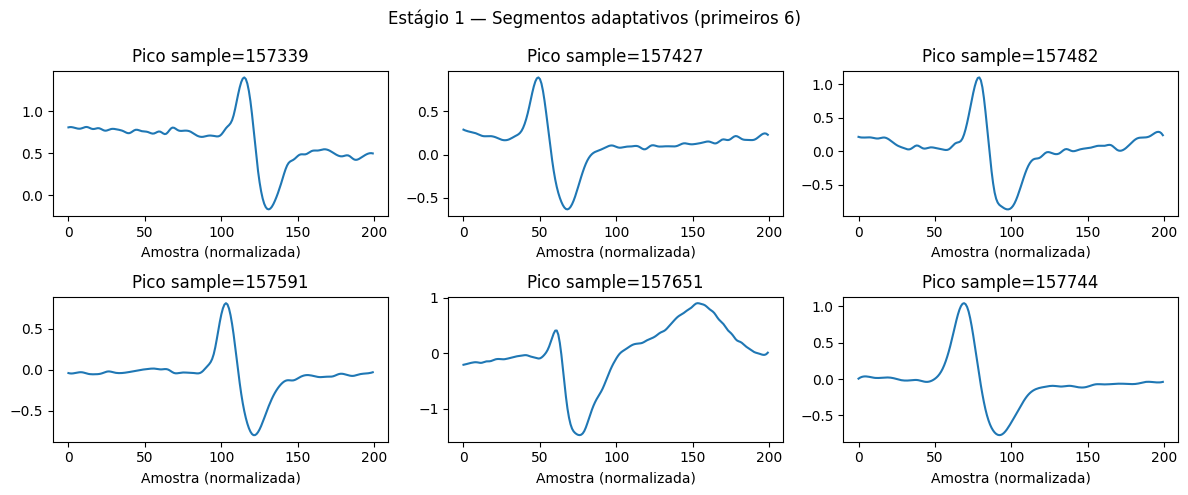

In [ ]:
# Verificação visual — primeiros 6 segmentos
n_plot = min(6, len(segments))
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i >= n_plot:
        ax.axis("off")
        continue
    ax.plot(segments[i])
    ax.set_title(f"{seg_df.iloc[i]['record_id']} | sample={seg_df.iloc[i]['sample']}")
    ax.set_xlabel("Amostra (normalizada)")
plt.suptitle("Estágio 1 — Segmentos adaptativos (primeiros segmentos)")
plt.tight_layout()
plt.show()


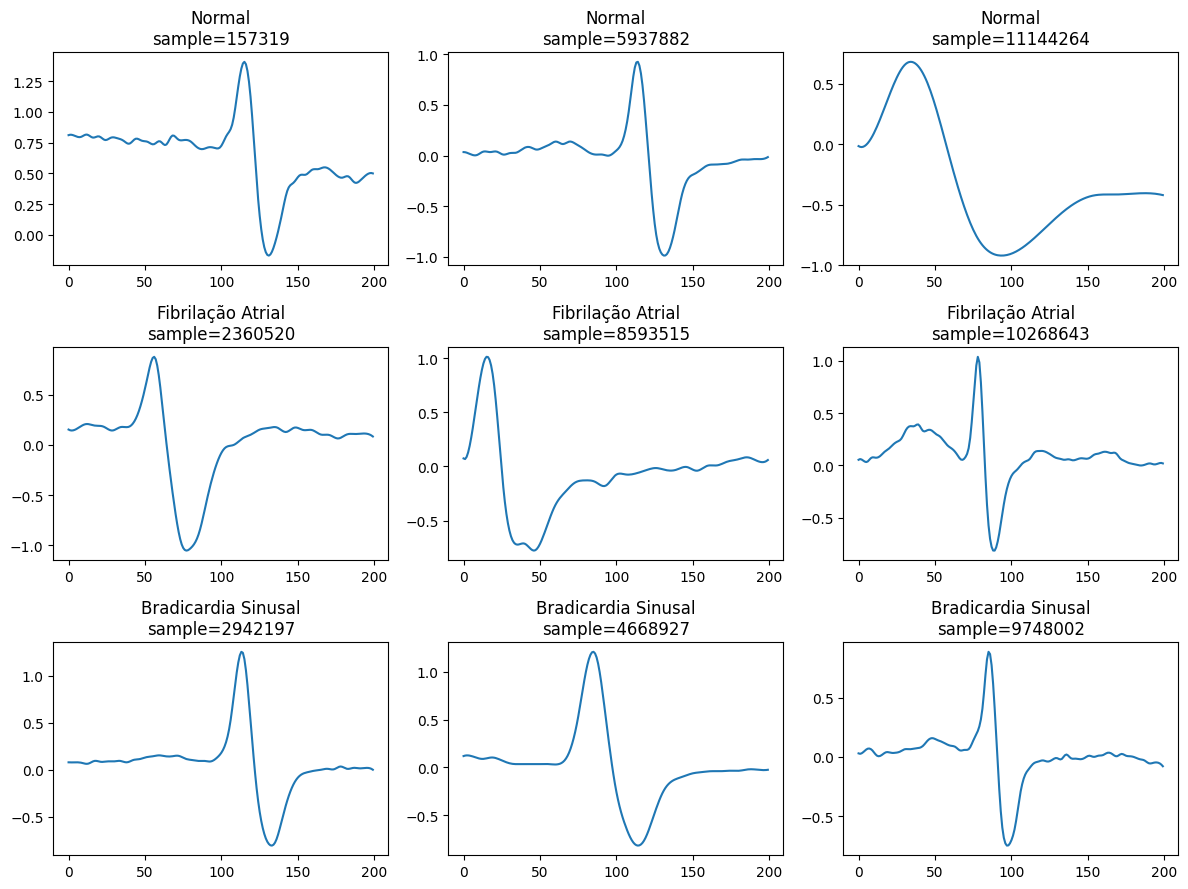

In [ ]:
# Verificação por ritmo — Normal, AFIB, Bradicardia
def plot_rhythm_comparison(seg_df, segments):
    ritmos = {"(N": "Normal", "(AFIB": "Fibrilação Atrial", "(SBR": "Bradicardia Sinusal"}
    fig, axes = plt.subplots(len(ritmos), 3, figsize=(12, 9))

    for row, (ritmo, label) in enumerate(ritmos.items()):
        idxs_available = seg_df.index[seg_df["rhythm"] == ritmo].to_numpy()

        if len(idxs_available) == 0:
            for col in range(3):
                axes[row, col].axis("off")
            continue

        idxs = np.linspace(0, len(idxs_available) - 1, min(3, len(idxs_available)), dtype=int)

        for col in range(3):
            if col >= len(idxs):
                axes[row, col].axis("off")
                continue

            seg_idx = idxs_available[idxs[col]]
            axes[row, col].plot(segments[seg_idx])
            axes[row, col].set_title(
                f"{label}\nrec={seg_df.loc[seg_idx, 'record_id']} | sample={seg_df.loc[seg_idx, 'sample']}"
            )

    plt.tight_layout()
    plt.show()

plot_rhythm_comparison(seg_df, segments)


## 5 — Estágio 2: CNN de Morfologia (N / A / V)

CNN 1D com 3 blocos Conv+BN+MaxPool → GlobalAveragePooling → Dense(64) → Dropout(0.5) → Softmax(3).

Input: segmentos de 200 amostras (saída do Estágio 1), filtrados e normalizados por batimento.
Split: 80% treino → SMOTE → 20% validação (sem SMOTE) | 20% teste (sem SMOTE).

In [9]:
# Dados do Estágio 2: CNN de morfologia
# Cada segmento já possui record_id, símbolo real, ritmo e fs em seg_df.
X2 = segments.copy()
y2 = seg_df["symbol"].values

# Filtro e normalização por batimento
X2 = np.array([
    bandpass(x, fs=row_fs)
    for x, row_fs in zip(X2, seg_df["fs"].values)
])
X2 = (X2 - X2.mean(axis=1, keepdims=True)) / (X2.std(axis=1, keepdims=True) + 1e-8)

le2 = LabelEncoder()
y2_enc = le2.fit_transform(y2)

print(f"Shape: {X2.shape}")
print(f"Classes: {le2.classes_}")
print(f"Distribuição: {dict(zip(le2.classes_, np.bincount(y2_enc)))}")


Shape: (124604, 200), Classes: ['A' 'N' 'V'], Dist: [12664 95311 16629]


In [10]:
# Split por registro/paciente, evitando misturar o mesmo paciente entre treino e teste
unique_records = np.array(sorted(seg_df["record_id"].unique()))

if len(unique_records) >= 3:
    train_records, test_records = train_test_split(
        unique_records,
        test_size=0.20,
        random_state=SEED
    )

    if len(train_records) >= 2:
        train_records, val_records = train_test_split(
            train_records,
            test_size=0.20,
            random_state=SEED
        )
    else:
        val_records = test_records

    train_mask = seg_df["record_id"].isin(train_records).values
    val_mask = seg_df["record_id"].isin(val_records).values
    test_mask = seg_df["record_id"].isin(test_records).values

    split_mode = "record-level"

else:
    # Fallback para não quebrar quando só existe um registro em data/.
    # Para resultado científico, use vários registros e evite este modo.
    idx = np.arange(len(X2))
    idx_train, idx_test = train_test_split(
        idx,
        test_size=0.20,
        random_state=SEED,
        stratify=y2_enc
    )
    idx_train, idx_val = train_test_split(
        idx_train,
        test_size=0.20,
        random_state=SEED,
        stratify=y2_enc[idx_train]
    )

    train_mask = np.zeros(len(X2), dtype=bool); train_mask[idx_train] = True
    val_mask = np.zeros(len(X2), dtype=bool); val_mask[idx_val] = True
    test_mask = np.zeros(len(X2), dtype=bool); test_mask[idx_test] = True

    train_records = seg_df.loc[train_mask, "record_id"].unique()
    val_records = seg_df.loc[val_mask, "record_id"].unique()
    test_records = seg_df.loc[test_mask, "record_id"].unique()

    split_mode = "beat-level fallback"

X2_train = X2[train_mask].reshape(-1, TARGET_LEN, 1)
X2_val = X2[val_mask].reshape(-1, TARGET_LEN, 1)
X2_test = X2[test_mask].reshape(-1, TARGET_LEN, 1)

y2_train = y2_enc[train_mask]
y2_val = y2_enc[val_mask]
y2_test = y2_enc[test_mask]

# Pesos de classe no lugar de SMOTE para evitar gerar batimentos artificiais
class_values = np.unique(y2_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=class_values,
    y=y2_train
)
class_weight2 = dict(zip(class_values, weights))

print(f"Modo de split: {split_mode}")
print(f"Train records ({len(train_records)}): {sorted(train_records)}")
print(f"Val records   ({len(val_records)}): {sorted(val_records)}")
print(f"Test records  ({len(test_records)}): {sorted(test_records)}")

print(f"\nTreino: {X2_train.shape}, Val: {X2_val.shape}, Teste: {X2_test.shape}")
print(f"Dist treino: {np.bincount(y2_train, minlength=len(le2.classes_))}")
print(f"Dist val:    {np.bincount(y2_val, minlength=len(le2.classes_))}")
print(f"Dist teste:  {np.bincount(y2_test, minlength=len(le2.classes_))}")
print(f"Class weights: {class_weight2}")


Treino: (182997, 200, 1), Val: (19937, 200, 1), Teste: (24921, 200, 1)
Dist treino: [60999 60999 60999], Dist val: [ 2026 15250  2661], Dist teste: [ 2533 19062  3326]


In [11]:
model2 = models.Sequential([
    layers.Input(shape=(200, 1)),
    layers.Conv1D(32, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,547 (174.01 KB)

 Trainable params: 44,099 (172.26 KB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
callbacks2 = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5)
]

history2 = model2.fit(
    X2_train, y2_train,
    epochs=30,
    batch_size=64,
    validation_data=(X2_val, y2_val),
    callbacks=callbacks2,
    class_weight=class_weight2
)


Epoch 1/30
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - accuracy: 0.7523 - loss: 0.5343 - val_accuracy: 0.8935 - val_loss: 0.3421 - learning_rate: 0.0010
Epoch 2/30
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 44s 15ms/step - accuracy: 0.7909 - loss: 0.4610 - val_accuracy: 0.7626 - val_loss: 0.5126 - learning_rate: 0.0010
Epoch 3/30
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 48s 17ms/step - accuracy: 0.8044 - loss: 0.4359 - val_accuracy: 0.8326 - val_loss: 0.3930 - learning_rate: 0.0010
Epoch 4/30
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 48s 17ms/step - accuracy: 0.8117 - loss: 0.4202 - val_accuracy: 0.7774 - val_loss: 0.5017 - learning_rate: 0.0010
Epoch 5/30
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - accuracy: 0.8252 - loss: 0.3939 - val_accuracy: 0.8952 - val_loss: 0.2928 - learning_rate: 5.0000e-04
Epoch 6/30
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - accuracy: 0.8304 - loss: 0.3833 - val_accuracy: 0.8326 - val_loss: 0.3800 - learning_rate: 5.0000e-04
Epoch 7/30
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 44s 15ms/step 

779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


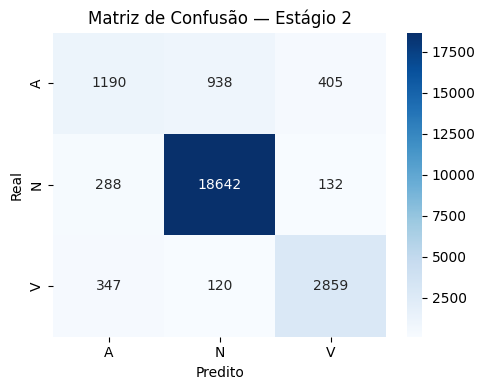

              precision    recall  f1-score   support

           A       0.65      0.47      0.55      2533
           N       0.95      0.98      0.96     19062
           V       0.84      0.86      0.85      3326

    accuracy                           0.91     24921
   macro avg       0.81      0.77      0.79     24921
weighted avg       0.90      0.91      0.90     24921

AUC A: 0.8782
AUC N: 0.9547
AUC V: 0.9889


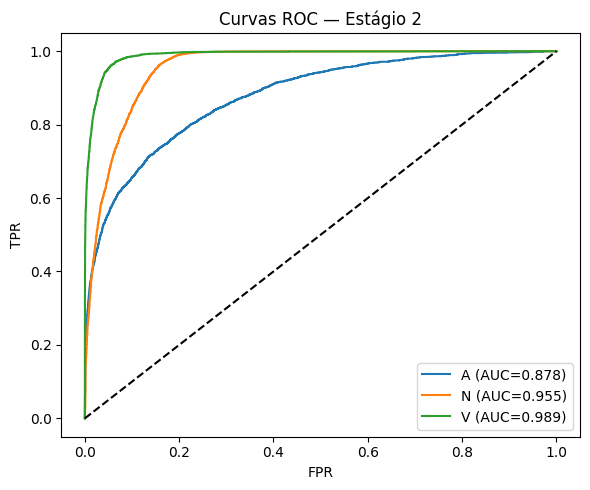

A → Sensitivity: 0.470 | Specificity: 0.972
N → Sensitivity: 0.978 | Specificity: 0.819
V → Sensitivity: 0.860 | Specificity: 0.975


In [13]:
# Avaliação — Estágio 2
y2_pred_proba = model2.predict(X2_test)
y2_pred = np.argmax(y2_pred_proba, axis=1)
classes = le2.classes_

# Confusion Matrix
cm2 = confusion_matrix(y2_test, y2_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Estágio 2')
plt.tight_layout(); plt.show()

print(classification_report(y2_test, y2_pred, target_names=classes))

# AUC
y2_test_bin = label_binarize(y2_test, classes=[0, 1, 2])
auc2_scores = roc_auc_score(y2_test_bin, y2_pred_proba, average=None)
for c, auc in zip(classes, auc2_scores):
    print(f"AUC {c}: {auc:.4f}")

# Curvas ROC
fig, ax = plt.subplots(figsize=(6, 5))
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y2_test_bin[:, i], y2_pred_proba[:, i])
    ax.plot(fpr, tpr, label=f"{c} (AUC={auc2_scores[i]:.3f})")
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curvas ROC — Estágio 2')
ax.legend(); plt.tight_layout(); plt.show()

# Sensitivity / Specificity
for i, c in enumerate(classes):
    tp = cm2[i, i]; fn = cm2[i, :].sum() - tp
    fp = cm2[:, i].sum() - tp; tn = cm2.sum() - tp - fn - fp
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"{c} → Sensitivity: {sens:.3f} | Specificity: {spec:.3f}")

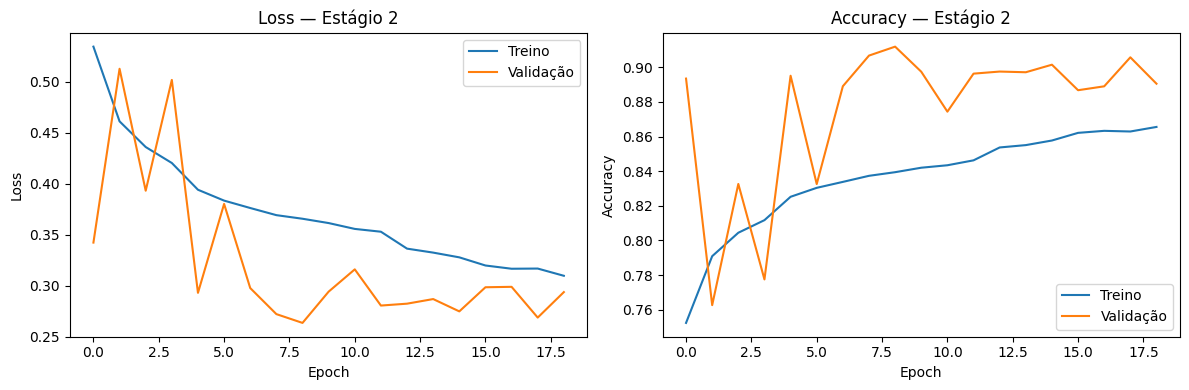

In [14]:
# Curvas de loss — Estágio 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history2.history['loss'], label='Treino')
axes[0].plot(history2.history['val_loss'], label='Validação')
axes[0].set_title('Loss — Estágio 2')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history2.history['accuracy'], label='Treino')
axes[1].plot(history2.history['val_accuracy'], label='Validação')
axes[1].set_title('Accuracy — Estágio 2')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout(); plt.show()

## 6 — Estágio 3: BiLSTM de Ritmo (Normal vs Anormal)

Janelas de 10s. Cada janela contém uma sequência de batimentos com 2 features: `[pred_symbol, rr_interval]`.

- `pred_symbol`: label do Estágio 2 (N=0, A=1, V=2)
- `rr`: intervalo entre batimentos em segundos (normalizado)

**Label da janela:** 0 = Normal (`N + (N` em todos os batimentos), 1 = Anormal (qualquer outro)

Arquitetura: BiLSTM(64) → Dropout → BiLSTM(32) → Dropout → Dense(32) → Sigmoid(1)

In [15]:
# Predições do model2 sobre todos os segmentos
X2_all = X2.reshape(-1, TARGET_LEN, 1)

pred_labels_all = le2.inverse_transform(
    np.argmax(model2.predict(X2_all, batch_size=512), axis=1)
)

beats = seg_df.copy().reset_index(drop=True)
beats["pred_symbol"] = pred_labels_all

# Label real de normalidade por batimento:
# normal = símbolo N e ritmo normal; caso contrário, potencialmente anormal.
beats["label"] = ((beats["symbol"] == "N") & (beats["rhythm"] == "(N")).astype(int)

# RR e BPM por registro, sem cruzar pacientes
beats = beats.sort_values(["record_id", "sample"]).reset_index(drop=True)
beats["rr"] = beats.groupby("record_id")["sample"].diff() / beats["fs"]
beats["rr"] = beats["rr"].fillna(0.0)

# Evitar BPM infinito no primeiro batimento de cada registro
beats["bpm"] = np.where(beats["rr"] > 0, 60.0 / beats["rr"], np.nan)

WINDOW_SEC = 10
beats["window_id"] = (beats["time_seconds"] // WINDOW_SEC).astype(int)

print(beats[["record_id", "sample", "symbol", "pred_symbol", "rr", "bpm", "window_id"]].head())


244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step
Janelas: 8584, Anormais: 7200, Normais: 1384


In [16]:
# Construção das janelas do Estágio 3 sem cruzar registros
# Features por batimento:
# 0: morfologia predita codificada
# 1: RR
# 2: BPM instantâneo
# 3: BPM médio da janela
# 4: desvio-padrão do BPM na janela
# 5: BPM mínimo da janela
# 6: BPM máximo da janela
# 7: número de batimentos na janela

MORPH_MAP = {"N": 0, "A": 1, "V": 2}
NORMAL_RATIO_THRESHOLD = 0.90

X_seq = []
y_seq = []
seq_lengths = []
window_records = []

for (rec_id, wid), group in beats.groupby(["record_id", "window_id"]):
    group = group.sort_values("sample")

    if len(group) < 3:
        continue

    rr = group["rr"].values.astype(float)
    bpm = group["bpm"].replace([np.inf, -np.inf], np.nan).values.astype(float)

    valid_bpm = bpm[~np.isnan(bpm)]
    if len(valid_bpm) == 0:
        mean_bpm = std_bpm = min_bpm = max_bpm = 0.0
    else:
        mean_bpm = float(np.mean(valid_bpm))
        std_bpm = float(np.std(valid_bpm))
        min_bpm = float(np.min(valid_bpm))
        max_bpm = float(np.max(valid_bpm))

    bpm = np.nan_to_num(bpm, nan=mean_bpm, posinf=mean_bpm, neginf=mean_bpm)
    symbol_enc = group["pred_symbol"].map(MORPH_MAP).values.astype(float)
    n_beats = float(len(group))

    seq = np.column_stack([
        symbol_enc,
        rr,
        bpm,
        np.full(len(group), mean_bpm),
        np.full(len(group), std_bpm),
        np.full(len(group), min_bpm),
        np.full(len(group), max_bpm),
        np.full(len(group), n_beats),
    ])

    normal_ratio = group["label"].mean()
    y = 0 if normal_ratio >= NORMAL_RATIO_THRESHOLD else 1

    X_seq.append(seq)
    y_seq.append(y)
    seq_lengths.append(len(seq))

    window_records.append({
        "record_id": rec_id,
        "window_id": wid,
        "dominant_morph": group["pred_symbol"].mode()[0],
        "dominant_rhythm": group["rhythm"].mode()[0],
        "mean_bpm": mean_bpm,
        "std_bpm": std_bpm,
        "min_bpm": min_bpm,
        "max_bpm": max_bpm,
        "n_beats": int(n_beats),
        "normal_ratio": normal_ratio,
        "y_true": y,
    })

window_df = pd.DataFrame(window_records)
y_arr = np.array(y_seq)
seq_lengths = np.array(seq_lengths)

MAX_BEATS = max(len(s) for s in X_seq)
N_FEATURES = X_seq[0].shape[1]

X_pad = pad_sequences(
    X_seq,
    maxlen=MAX_BEATS,
    dtype="float32",
    padding="post",
    value=0.0
)

print(f"Janelas: {len(X_seq)}")
print(f"Shape bruto: {X_pad.shape}")
print(f"Anormais: {sum(y_seq)}, Normais: {len(y_seq) - sum(y_seq)}")
window_df.head()


Shape: (8584, 35, 2)


In [17]:
# Split do Estágio 3 por registro, alinhado ao split do Estágio 2
if split_mode == "record-level":
    train_win_mask = window_df["record_id"].isin(train_records).values
    val_win_mask = window_df["record_id"].isin(val_records).values
    test_win_mask = window_df["record_id"].isin(test_records).values
else:
    # fallback para um único registro: split por janela
    win_idx = np.arange(len(window_df))
    idx_train_w, idx_test_w = train_test_split(
        win_idx,
        test_size=0.20,
        random_state=SEED,
        stratify=y_arr
    )
    idx_train_w, idx_val_w = train_test_split(
        idx_train_w,
        test_size=0.20,
        random_state=SEED,
        stratify=y_arr[idx_train_w]
    )

    train_win_mask = np.zeros(len(window_df), dtype=bool); train_win_mask[idx_train_w] = True
    val_win_mask = np.zeros(len(window_df), dtype=bool); val_win_mask[idx_val_w] = True
    test_win_mask = np.zeros(len(window_df), dtype=bool); test_win_mask[idx_test_w] = True

X3_train = X_pad[train_win_mask].copy()
X3_val = X_pad[val_win_mask].copy()
X3_test = X_pad[test_win_mask].copy()

y3_train = y_arr[train_win_mask]
y3_val = y_arr[val_win_mask]
y3_test = y_arr[test_win_mask]

len_train = seq_lengths[train_win_mask]
len_val = seq_lengths[val_win_mask]
len_test = seq_lengths[test_win_mask]

def valid_position_mask(lengths, max_len):
    mask = np.zeros((len(lengths), max_len), dtype=bool)
    for i, length in enumerate(lengths):
        mask[i, :length] = True
    return mask

valid_train = valid_position_mask(len_train, MAX_BEATS)
valid_val = valid_position_mask(len_val, MAX_BEATS)
valid_test = valid_position_mask(len_test, MAX_BEATS)

# Normalização sem vazamento:
# calcula estatísticas APENAS nas posições reais do treino.
# Não normaliza a coluna 0, pois ela é a classe morfológica codificada.
train_real_values = X3_train[:, :, 1:][valid_train]
feature_means = train_real_values.mean(axis=0, keepdims=True).reshape(1, 1, -1)
feature_stds = train_real_values.std(axis=0, keepdims=True).reshape(1, 1, -1)

X3_train[:, :, 1:] = (X3_train[:, :, 1:] - feature_means) / (feature_stds + 1e-8)
X3_val[:, :, 1:] = (X3_val[:, :, 1:] - feature_means) / (feature_stds + 1e-8)
X3_test[:, :, 1:] = (X3_test[:, :, 1:] - feature_means) / (feature_stds + 1e-8)

# Zera padding depois da normalização para a camada Masking ignorar corretamente.
X3_train[~valid_train] = 0.0
X3_val[~valid_val] = 0.0
X3_test[~valid_test] = 0.0

# Pesos de classe no lugar de SMOTE para preservar sequências reais
class_values3 = np.unique(y3_train)
weights3 = compute_class_weight(
    class_weight="balanced",
    classes=class_values3,
    y=y3_train
)
class_weight3 = dict(zip(class_values3, weights3))

print(f"Treino: {X3_train.shape}, Val: {X3_val.shape}, Teste: {X3_test.shape}")
print(f"Dist treino: {np.bincount(y3_train, minlength=2)}")
print(f"Dist val:    {np.bincount(y3_val, minlength=2)}")
print(f"Dist teste:  {np.bincount(y3_test, minlength=2)}")
print(f"Class weights: {class_weight3}")


Treino: (9214, 35, 2), Val: (1374, 35, 2), Teste: (1717, 35, 2)
Dist treino: [4607 4607], Dist teste: [ 277 1440]


In [18]:
model3 = models.Sequential([
    layers.Input(shape=(MAX_BEATS, N_FEATURES)),
    layers.Masking(mask_value=0.0),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Dropout(0.3),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 35, 128)        │        34,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 35, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,633 (303.25 KB)

 Trainable params: 77,633 (303.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
callbacks3 = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5)
]

history3 = model3.fit(
    X3_train, y3_train,
    epochs=30,
    batch_size=64,
    validation_data=(X3_val, y3_val),
    callbacks=callbacks3,
    class_weight=class_weight3
)


Epoch 1/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8512 - loss: 0.3637 - val_accuracy: 0.8683 - val_loss: 0.2528 - learning_rate: 0.0010
Epoch 2/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8765 - loss: 0.2986 - val_accuracy: 0.8384 - val_loss: 0.3014 - learning_rate: 0.0010
Epoch 3/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8827 - loss: 0.2748 - val_accuracy: 0.8443 - val_loss: 0.3557 - learning_rate: 0.0010
Epoch 4/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8921 - loss: 0.2710 - val_accuracy: 0.8610 - val_loss: 0.2665 - learning_rate: 0.0010
Epoch 5/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9060 - loss: 0.2403 - val_accuracy: 0.8930 - val_loss: 0.2374 - learning_rate: 5.0000e-04
Epoch 6/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9137 - loss: 0.2275 - val_accuracy: 0.8850 - val_loss: 0.2667 - learning_rate: 5.0000e-04
Epoch 7/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9151 -

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


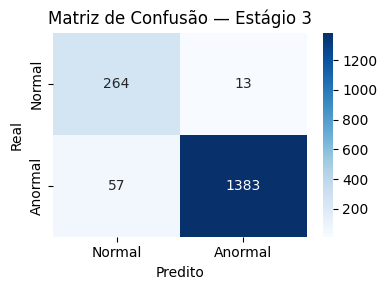

              precision    recall  f1-score   support

      Normal       0.82      0.95      0.88       277
     Anormal       0.99      0.96      0.98      1440

    accuracy                           0.96      1717
   macro avg       0.91      0.96      0.93      1717
weighted avg       0.96      0.96      0.96      1717

AUC: 0.9872


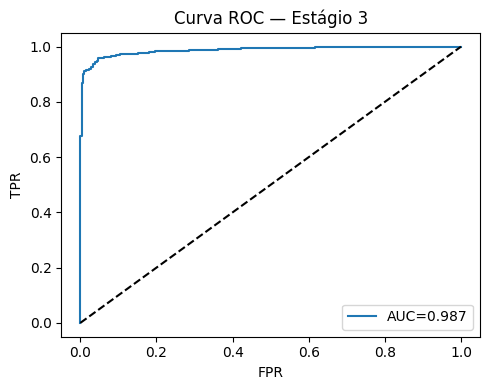

Sensitivity: 0.960 | Specificity: 0.953


In [20]:
# Avaliação — Estágio 3
y3_pred_proba = model3.predict(X3_test).flatten()
y3_pred = (y3_pred_proba >= 0.5).astype(int)

# Confusion Matrix
cm3 = confusion_matrix(y3_test, y3_pred)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm3, annot=True, fmt='d',
            xticklabels=['Normal', 'Anormal'],
            yticklabels=['Normal', 'Anormal'], cmap='Blues')
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Estágio 3')
plt.tight_layout(); plt.show()

print(classification_report(y3_test, y3_pred, target_names=['Normal', 'Anormal']))

if len(np.unique(y3_test)) == 2:
    auc3 = roc_auc_score(y3_test, y3_pred_proba)
    print(f"AUC: {auc3:.4f}")

    # Curva ROC
    fpr, tpr, _ = roc_curve(y3_test, y3_pred_proba)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'AUC={auc3:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title('Curva ROC — Estágio 3')
    plt.legend(); plt.tight_layout(); plt.show()
else:
    auc3 = None
    print("AUC não calculada: o conjunto de teste possui apenas uma classe.")

tn, fp, fn, tp = cm3.ravel() if cm3.size == 4 else (0, 0, 0, 0)
sens = tp / (tp + fn) if (tp + fn) > 0 else 0
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"Sensitivity: {sens:.3f} | Specificity: {spec:.3f}")


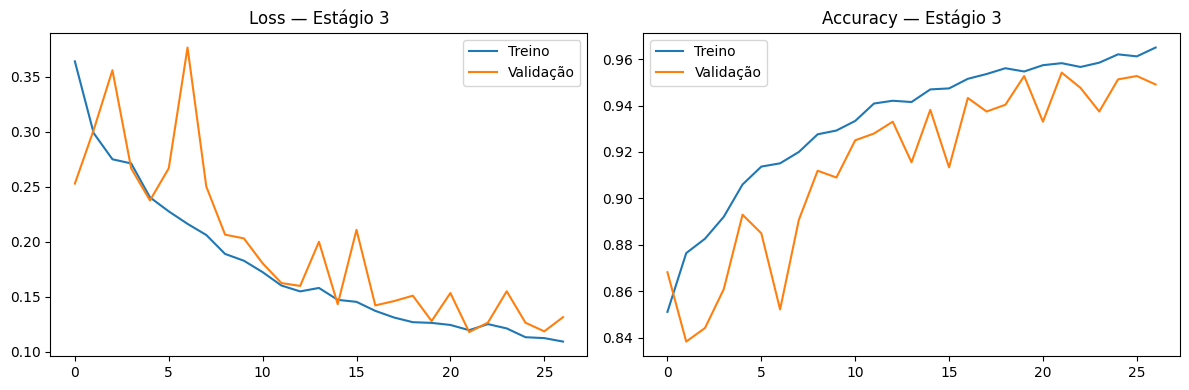

In [21]:
# Curvas de loss — Estágio 3
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history3.history['loss'], label='Treino')
axes[0].plot(history3.history['val_loss'], label='Validação')
axes[0].set_title('Loss — Estágio 3'); axes[0].legend()

axes[1].plot(history3.history['accuracy'], label='Treino')
axes[1].plot(history3.history['val_accuracy'], label='Validação')
axes[1].set_title('Accuracy — Estágio 3'); axes[1].legend()

plt.tight_layout(); plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


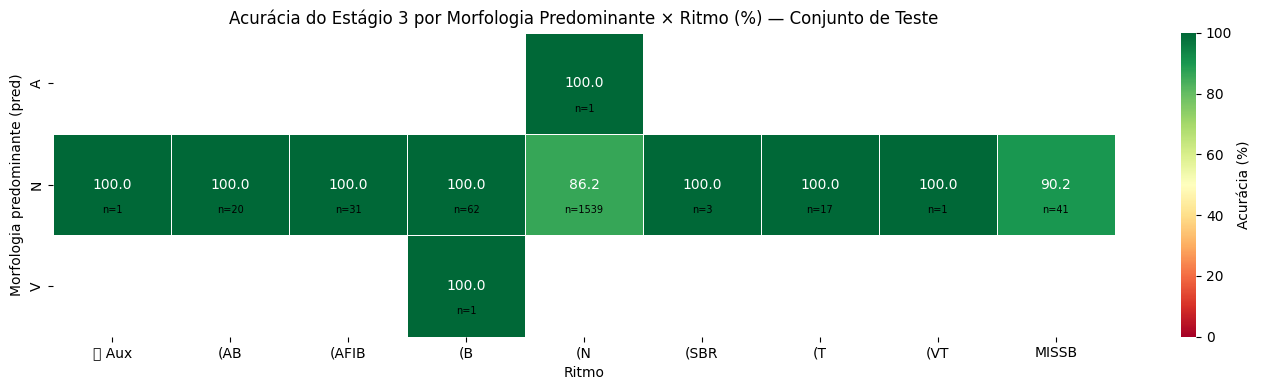

In [22]:
# Análise do Estágio 3 por morfologia, ritmo, BPM e paciente/registro
df_test = window_df.loc[test_win_mask].copy().reset_index(drop=True)

df_test["y_pred_proba"] = y3_pred_proba
df_test["y_pred"] = y3_pred
df_test["correct"] = (df_test["y_true"] == df_test["y_pred"]).astype(int)

def bpm_group(mean_bpm):
    if mean_bpm < 60:
        return "baixo_BPM_<60"
    elif mean_bpm <= 100:
        return "normal_BPM_60_100"
    else:
        return "alto_BPM_>100"

df_test["bpm_group"] = df_test["mean_bpm"].apply(bpm_group)

print("Métricas por faixa de BPM:")
for group_name, group_df in df_test.groupby("bpm_group"):
    print(f"\n--- {group_name} | n={len(group_df)} ---")
    print(classification_report(
        group_df["y_true"],
        group_df["y_pred"],
        target_names=["Normal", "Anormal"],
        zero_division=0
    ))

print("\nAcurácia por registro/paciente:")
display(
    df_test.groupby("record_id")["correct"]
    .agg(["mean", "count"])
    .sort_values("mean")
)

# Heatmap: morfologia predominante x ritmo dominante
pivot = (
    df_test
    .groupby(["dominant_morph", "dominant_rhythm"])["correct"]
    .agg(["mean", "count"])
    .reset_index()
)
pivot["mean"] = (pivot["mean"] * 100).round(1)

acc_matrix = pivot.pivot(index="dominant_morph", columns="dominant_rhythm", values="mean")
count_matrix = pivot.pivot(index="dominant_morph", columns="dominant_rhythm", values="count")

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(acc_matrix, annot=True, fmt=".1f", cmap="RdYlGn",
            vmin=0, vmax=100, ax=ax,
            linewidths=0.5, cbar_kws={"label": "Acurácia (%)"})

for i in range(acc_matrix.shape[0]):
    for j in range(acc_matrix.shape[1]):
        val = count_matrix.iloc[i, j]
        if not np.isnan(val):
            ax.text(j + 0.5, i + 0.75, f"n={int(val)}",
                    ha="center", va="center", fontsize=7, color="black")

ax.set_title("Acurácia do Estágio 3 por Morfologia Predominante × Ritmo (%) — Teste")
ax.set_xlabel("Ritmo")
ax.set_ylabel("Morfologia predominante")
plt.tight_layout()
plt.show()

# Heatmap: faixa de BPM
bpm_acc = (
    df_test
    .groupby("bpm_group")["correct"]
    .agg(["mean", "count"])
    .reset_index()
)
bpm_acc["accuracy_%"] = (bpm_acc["mean"] * 100).round(1)
display(bpm_acc[["bpm_group", "accuracy_%", "count"]])


In [25]:
# Salvamento do modelo de morfologia
os.makedirs("models", exist_ok=True)

MODEL2_PATH = "models/clean_model2_morphology.keras"
model2.save(MODEL2_PATH)

print(f"model2 salvo em: {MODEL2_PATH}")


model2 treinado e salvo


In [26]:
# Salvamento do modelo de ritmo
MODEL3_PATH = "models/clean_model3_rhythm.keras"
model3.save(MODEL3_PATH)

print(f"model3 salvo em: {MODEL3_PATH}")


model3 treinado e salvo


In [27]:
# Salvamento de metadados necessários para inferência/reprodutibilidade
metadata = {
    "records": list(RECORDS),
    "failed_records": failed_records,
    "split_mode": split_mode,
    "train_records": list(map(str, train_records)),
    "val_records": list(map(str, val_records)),
    "test_records": list(map(str, test_records)),
    "target_len": TARGET_LEN,
    "window_sec": WINDOW_SEC,
    "max_beats": MAX_BEATS,
    "n_features_stage3": N_FEATURES,
    "morph_map": MORPH_MAP,
    "normal_ratio_threshold": NORMAL_RATIO_THRESHOLD,
    "stage2_classes": le2.classes_.tolist(),
    "stage3_feature_means": feature_means.flatten().tolist(),
    "stage3_feature_stds": feature_stds.flatten().tolist(),
    "bandpass": {
        "low": 0.5,
        "high": 40,
        "order": 3,
    },
}

with open("models/preprocessing_metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

with open("models/le2.pkl", "wb") as f:
    pickle.dump(le2, f)

print("Metadados salvos em: models/preprocessing_metadata.pkl")
print("LabelEncoder salvo em: models/le2.pkl")


['models/le2.pkl']